In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd

In [30]:
df_CO2 = pd.read_csv('/Users/siobhankassem/Desktop/USC/Classes/Fall 2026/Python Data Science/Datasets/ManuaLoa_CO2.csv')
df_EPA = pd.read_csv('/Users/siobhankassem/Desktop/USC/Classes/Fall 2026/Python Data Science/Datasets/LA_AQS_2023.csv') 

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,6,37,1103,68103,1,34.06659,-118.22688,WGS84,Ambient Min Temperature,24 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,62101,1,34.06659,-118.22688,WGS84,Outdoor Temperature,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,42603,1,34.06659,-118.22688,WGS84,Oxides of nitrogen (NOx),1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [44]:
df_CO2.head()
df_CO2.columns

Index(['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays',
       'sdev', 'unc'],
      dtype='str')

In [129]:
O3 = df_EPA[(df_EPA['Parameter Name'] == 'Ozone') & (df_EPA['Duration Description']=='1 HOUR')]

O3.columns

Index(['State Code', 'County Code', 'Site Number', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name',
       'Duration Description', 'Pollutant Standard', 'Date (Local)', 'Year',
       'Day In Year (Local)', 'Units of Measure', 'Exceptional Data Type',
       'Nonreg Observation Count', 'Observation Count', 'Observation Percent',
       'Nonreg Arithmetic Mean', 'Arithmetic Mean',
       'Nonreg First Maximum Value', 'First Maximum Value',
       'First Maximum Hour', 'AQI', 'Daily Criteria Indicator', 'Tribe Name',
       'State Name', 'County Name', 'City Name', 'Local Site Name', 'Address',
       'MSA or CBSA Name', 'Data Source'],
      dtype='str')

Text(0.5, 1.0, 'Ozone Arithmetic Mean')

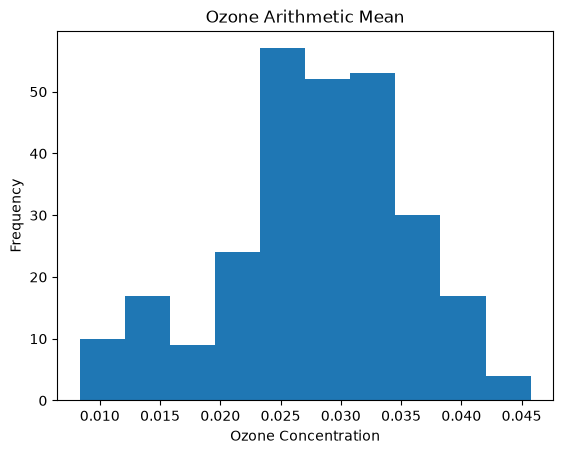

In [130]:
plt.hist(O3['Arithmetic Mean'])
plt.xlabel('Ozone Concentration')
plt.ylabel('Frequency')
plt.title('Ozone Arithmetic Mean')

# this is showing that the majority or mean ozone concentrations are between 0.025 - 0.035. 

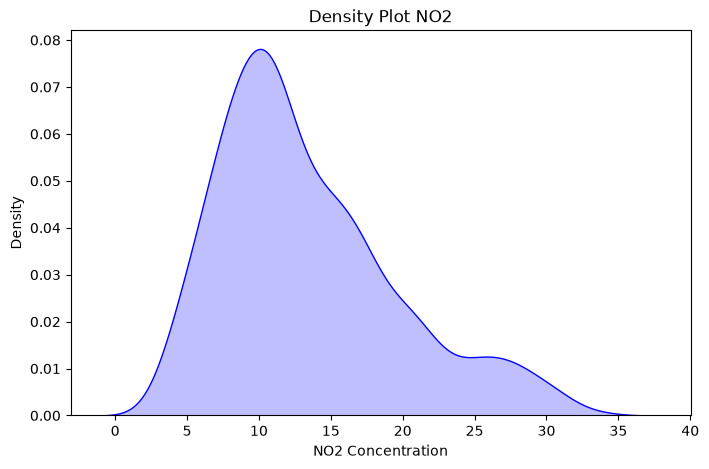

In [131]:
NO2 = df_EPA[df_EPA['Parameter Name'] == 'Nitrogen dioxide (NO2)']
plt.figure(figsize=(8, 5))
sns.kdeplot(data=NO2, x=NO2['Arithmetic Mean'], fill=True, color="blue")
plt.title("Density Plot NO2")
plt.xlabel("NO2 Concentration")
plt.ylabel("Density")
plt.show()

# this shows me that the most NO2 concentrations are around 10

In [132]:
O3_conc = pd.DataFrame(data = {"O3 Conc" : O3['Arithmetic Mean'], 'date' : O3['Date (Local)']})
NO2_conc = pd.DataFrame(data = {"NO2 Conc" : NO2['Arithmetic Mean'], 'date' : NO2['Date (Local)']})
conc_all = O3_conc.merge(NO2_conc, on=['date'])

In [133]:
NO2.columns

Index(['State Code', 'County Code', 'Site Number', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name',
       'Duration Description', 'Pollutant Standard', 'Date (Local)', 'Year',
       'Day In Year (Local)', 'Units of Measure', 'Exceptional Data Type',
       'Nonreg Observation Count', 'Observation Count', 'Observation Percent',
       'Nonreg Arithmetic Mean', 'Arithmetic Mean',
       'Nonreg First Maximum Value', 'First Maximum Value',
       'First Maximum Hour', 'AQI', 'Daily Criteria Indicator', 'Tribe Name',
       'State Name', 'County Name', 'City Name', 'Local Site Name', 'Address',
       'MSA or CBSA Name', 'Data Source'],
      dtype='str')

In [134]:
O3_all = conc_all['O3 Conc']
NO2_all = conc_all['NO2 Conc']

conc_all.head()

,O3 Conc,date,NO2 Conc
0,0.031708,2023-01-01,4.816667
1,0.031708,2023-01-01,4.550000
2,0.031708,2023-01-01,4.550000
3,0.031708,2023-01-01,4.816667
4,0.015792,2023-01-02,14.720833


Text(0, 0.5, 'NO2 Concentration (ppb)')

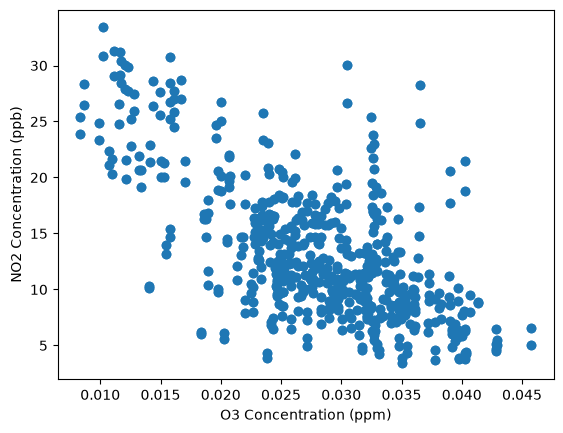

In [146]:
plt.scatter(O3_all,NO2_all)
plt.xlabel('O3 Concentration (ppm)')
plt.ylabel('NO2 Concentration (ppb)')

# this is showing that there is a negative relationship between NO2 and ozone. 

In [151]:
O3_35 = O3[O3['Arithmetic Mean']*1000 > 35]
O3_35['Date (Local)']
# no 01, 10, 11, 12 months?

4651     2023-02-22
4928     2023-02-25
5235     2023-03-01
7130     2023-03-21
7337     2023-03-24
7679     2023-03-26
7883     2023-03-29
8427     2023-04-03
8447     2023-04-04
9439     2023-04-14
9646     2023-04-17
9838     2023-04-18
10181    2023-04-22
10226    2023-04-23
10448    2023-04-24
10541    2023-04-25
10584    2023-04-26
10869    2023-04-30
12292    2023-05-14
12375    2023-05-15
12893    2023-05-20
12914    2023-05-21
13434    2023-05-25
13641    2023-05-28
13684    2023-05-29
13792    2023-05-30
14246    2023-06-04
14475    2023-06-05
14590    2023-06-06
17251    2023-07-09
18314    2023-07-29
18345    2023-07-30
19828    2023-08-29
20206    2023-09-06
20262    2023-09-08
20558    2023-09-14
20625    2023-09-15
20675    2023-09-16
20720    2023-09-17
20763    2023-09-18
20849    2023-09-20
21218    2023-09-28
21261    2023-09-29
Name: Date (Local), dtype: str

In [168]:
date_35 = O3_35['Date (Local)']
mon = date_35.str[5:7]
yr = date_35.str[0:4]
days_35 = pd.DataFrame({'date': date_35,'month': mon, 'yr': yr, 'O3':O3_35['Arithmetic Mean'] * 1000})
days_35.head()

,date,month,yr,O3
4651,2023-02-22,02,2023,36.042
4928,2023-02-25,02,2023,39.208
5235,2023-03-01,03,2023,40.250
7130,2023-03-21,03,2023,41.381
7337,2023-03-24,03,2023,42.875


(array([ 2.,  5., 11.,  8.,  3.,  3.,  1., 10.]),
 array([2.   , 2.875, 3.75 , 4.625, 5.5  , 6.375, 7.25 , 8.125, 9.   ]),
 <BarContainer object of 8 artists>)

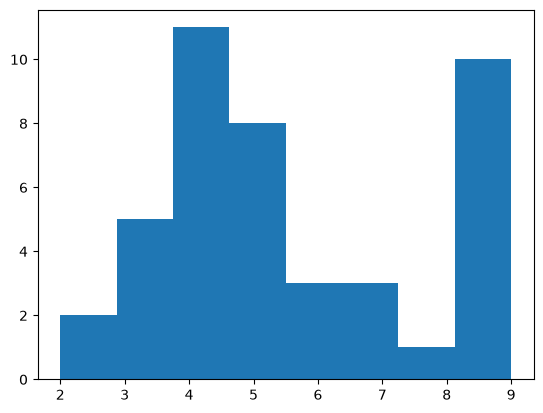

In [176]:
mon_int = mon.astype(int)
plt.hist(mon_int, bins=8)

#plotting again for fun using another method

(array([ 2.,  5., 11.,  8.,  0.,  3.,  3.,  1., 10.]),
 array([0.        , 0.77777778, 1.55555556, 2.33333333, 3.11111111,
        3.88888889, 4.66666667, 5.44444444, 6.22222222, 7.        ]),
 <BarContainer object of 9 artists>)

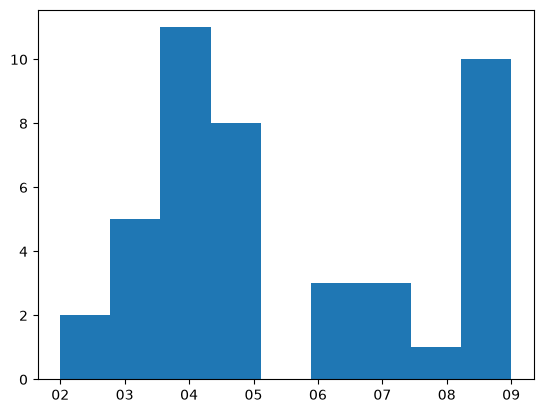

In [162]:
plt.hist(mon,bins=9)

In [149]:
days_35_unique = days_35.drop_duplicates(subset='date')
monthly_count = days_35_unique['month'].value_counts().sort_index()
monthly_count

month
02     2
03     5
04    11
05     8
06     3
07     3
08     1
09    10
Name: count, dtype: int64

Text(0, 0.5, 'Days with O3 >35 ppb')

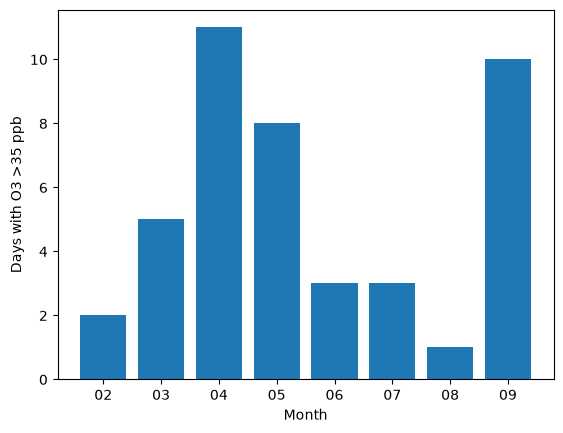

In [158]:
plt.bar(monthly_count.index, monthly_count.values)
plt.xlabel('Month')
plt.ylabel('Days with O3 >35 ppb')

In [102]:
df_CO2.columns

Index(['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays',
       'sdev', 'unc'],
      dtype='str')

Text(0.5, 1.0, 'Mauna Loa CO2 (ppm)')

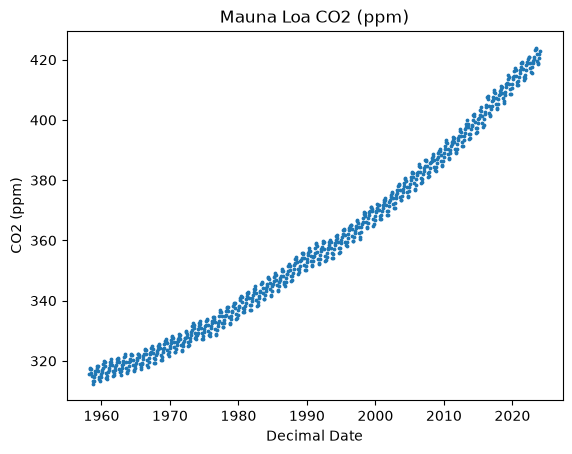

In [112]:
# scatter plot of average CO2

plt.scatter(df_CO2['decimal date'], df_CO2['average'], s=3)
plt.xlabel('Decimal Date')
plt.ylabel('CO2 (ppm)')
plt.title('Mauna Loa CO2 (ppm)')

Text(0.5, 1.0, 'Enter title here')

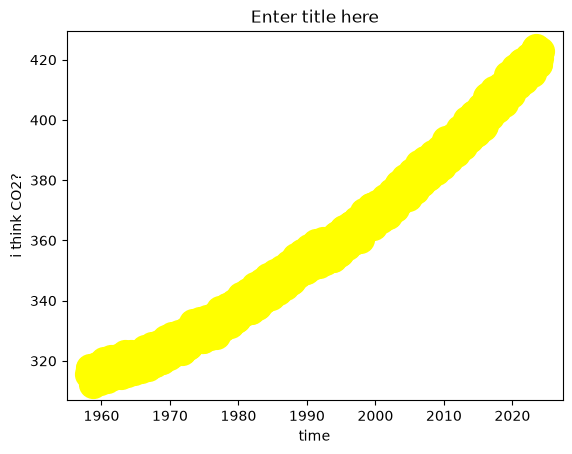

In [179]:

plt.scatter(df_CO2['decimal date'], df_CO2['average'], s=400, color='yellow')
plt.xlabel('time')
plt.ylabel('i think CO2?')
plt.title('Enter title here')